<a href="https://colab.research.google.com/github/arya-arun-123/Blood_Cell_Classification_Model/blob/main/PCB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LIBRARIES

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import  classification_report,confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# READ DATASET

In [3]:
# dataset
filepath= "/content/drive/MyDrive/ICT AIML/Datasets/cnn proj/PBC_dataset_normal_DIB"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42


### inspect classes

In [4]:
classes = sorted(
    d for d in os.listdir(filepath)
    if os.path.isdir(os.path.join(filepath, d))
)
NUM_CLASSES = len(classes)

print("Classes Found:\n")
class_counts = {}
for cls in classes:
    class_path = os.path.join(filepath, cls)
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    class_counts[cls] = len(images)
    print(f"{cls:<15} : {len(images)} images")

print(f"\nTotal classes: {NUM_CLASSES}")

Classes Found:

basophil        : 1218 images
eosinophil      : 3117 images
erythroblast    : 1551 images
ig              : 2895 images
lymphocyte      : 1214 images
monocyte        : 1420 images
neutrophil      : 3329 images
platelet        : 2348 images

Total classes: 8


# CREATING TRAINING AND TESTING DATASET

In [5]:
# TRAINING DATASET
# 70 % used for training

train_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle=True
)

Found 17092 files belonging to 8 classes.
Using 11965 files for training.


In [6]:
temp_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)


Found 17092 files belonging to 8 classes.
Using 5127 files for validation.


In [7]:
class_names = train_ds.class_names
assert class_names == classes, "Class order mismatch between directory scan and dataset!"
assert len(class_names) == NUM_CLASSES

In [8]:
# VALIDATION AND TEST DATASET
# 15 % - validation datset
# 15 % - testing dataset
temp_batches = tf.data.experimental.cardinality(temp_ds)

val_ds = temp_ds.take(temp_batches // 2)
test_ds = temp_ds.skip(temp_batches // 2)

print("Class order:", class_names)

Class order: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


# AUTO TUNING

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size = AUTOTUNE)

# This allows to load next batch while training current batch

### CLASS WEIGHTS

In [10]:
labels = list(class_counts.keys())
counts = np.array(list(class_counts.values()))
y_all = np.repeat(np.arange(NUM_CLASSES), counts)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_all
)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight)

Class weights: {0: np.float64(1.7541050903119868), 1: np.float64(0.6854347128649342), 2: np.float64(1.377498388136686), 3: np.float64(0.7379965457685665), 4: np.float64(1.7598846787479407), 5: np.float64(1.5045774647887324), 6: np.float64(0.6417843196155002), 7: np.float64(0.909923339011925)}


# AUGMENTATION

In [11]:
# Makes changes in training data to prevent overfitting and improve generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10)
])

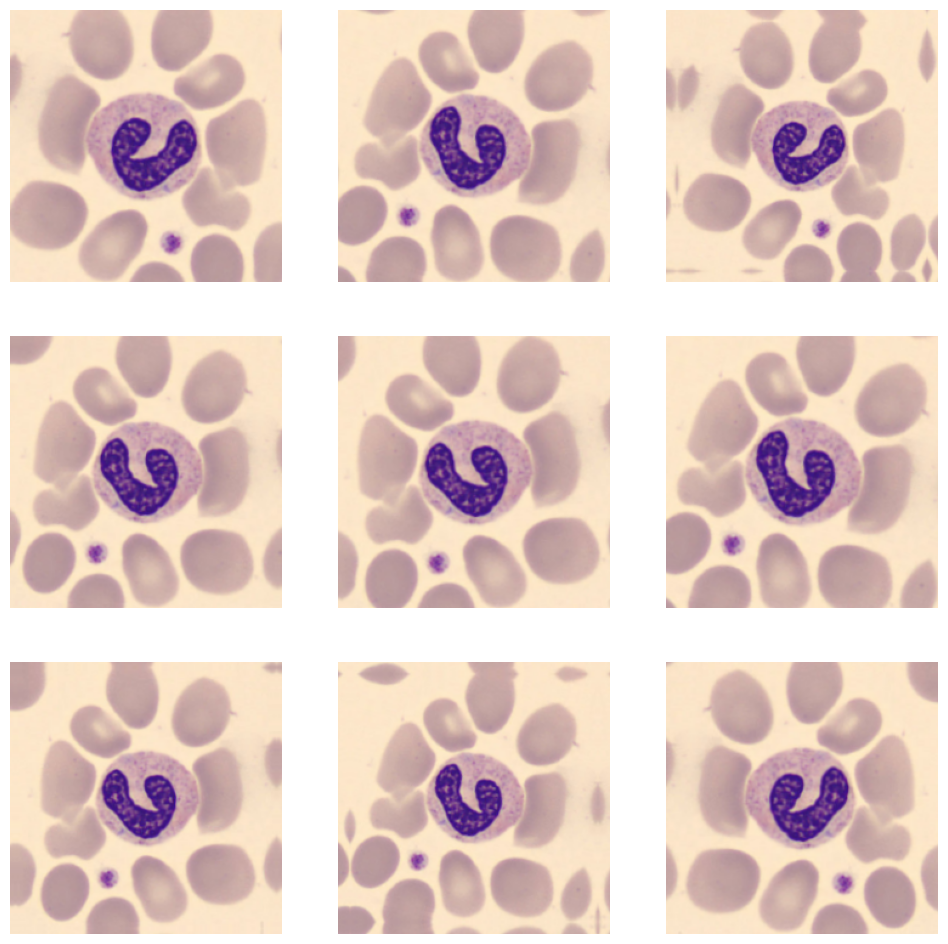

In [12]:
for images, labels in train_ds.take(1):

    plt.figure(figsize = (12, 12))
    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")

plt.show()

# NORMALIZATION

In [13]:
normalization_layer = layers.Rescaling(1./255)

# MODEL BUILDING

### MODEL 1 : CUSTOM CNN

In [14]:
cnn_model = tf.keras.Sequential([
    tf.keras.Input(shape = (IMG_SIZE[0],IMG_SIZE[1], 3)),
    data_augmentation,
    normalization_layer,
    # LAYER 1
    layers.Conv2D(
        filters = 32,
        kernel_size = (3,3),
        activation ='relu',
        padding ='same'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Dropout(0.25),



    # LAYER 2
    layers.Conv2D(
        filters = 64,
        kernel_size = (3,3),
        activation ='relu',
        padding ='same'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Dropout(0.25),



    # LAYER 3
    layers.Conv2D(
        filters = 128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Dropout(0.30),



    # OUTPUT LAYER
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.50),
    layers.Dense(NUM_CLASSES, activation='softmax')

], name = "custom_cnn")

# COMPILING THE MODEL

In [15]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# CALLBACKS

In [16]:
# Early Stopping
cnn_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

In [17]:
# Checkpointing
cnn_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [18]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# MODEL TRAINING

In [ ]:
cnn_history = cnn_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 5,
    callbacks=[cnn_early_stop, cnn_checkpoint],
    class_weight = class_weight
)

Epoch 1/5
 82/374 ━━━━━━━━━━━━━━━━━━━━ 30:18 6s/step - accuracy: 0.2664 - loss: 20.4431

# MODEL 2 VGG Transfer Learning


## Load the Pre-trained VGG16 Model

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False   # freeze pretrained backbone

## Building new model

In [ ]:
vgg_model = Sequential([
    tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,                       # FIX: augmentation now applied here too
    Lambda(preprocess_input),                # FIX: correct VGG16 preprocessing (was missing)
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')  # FIX: tied to actual class count
], name="vgg16_transfer")

vgg_model.summary()

## Compile the model

In [ ]:
vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Call backs

In [ ]:
vgg_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

vgg_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_vgg_model.keras",       # FIX: unique filename, no longer collides with the CNN's checkpoint
    monitor='val_accuracy',
    save_best_only=True
)

## Train the model

In [ ]:
vgg_history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[vgg_early_stop, vgg_checkpoint],
    class_weight=class_weight
)

## Evaluate the model

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

#Final Evaluation

In [ ]:
def evaluate_on_test(model, test_ds, class_names):
    loss, accuracy = model.evaluate(test_ds)
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

    y_true = []
    y_pred = []
    for images, labels_batch in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels_batch.numpy())

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=90)
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return y_true, y_pred

In [ ]:
print("=== Custom CNN ===")
cnn_y_true, cnn_y_pred = evaluate_on_test(cnn_model, test_ds, class_names)

In [ ]:
print("=== VGG16 Transfer Learning ===")
vgg_y_true, vgg_y_pred = evaluate_on_test(vgg_model, test_ds, class_names)

## Save the model


In [ ]:
cnn_model.save("custom_cnn_pcb.keras")
vgg_model.save("vgg16_pcb.keras")